# Regression

Before reaching for boosting: a logistic regression on the same features. It is weaker, but its coefficients are directly readable as odds ratios, which answers *what moves the needle* in a way tree gain never quite does. The AUC gap to LightGBM is the price of that interpretability.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import INTERIM, ROOT
from src.models import time_split

FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"
POS, NEG, SLOT1, SLOT2 = "#2a78d6", "#e34948", "#2a78d6", "#eb6834"
CUTOFF, CATS = "2015-07-01", ["deviceID", "paymentMethod"]
DROP = ["orderID", "orderDate", "customerID", "any_return"]

df = pd.read_parquet(INTERIM / "orders.parquet")
for block in ["basket", "customer", "article"]:
    df = df.merge(pd.read_parquet(INTERIM / f"{block}.parquet"), on="orderID", how="left")
df.shape

(738698, 40)

## Matrix

**Everything LightGBM did for free, done by hand.** One-hot encoding (`drop_first` avoids the dummy trap), median imputation (logistic regression cannot accept NaN at all), and standardisation fitted on *train only* — fitting the scaler on all rows would leak the validation distribution into training.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss

FEATS = [c for c in df.columns if c not in DROP + ["cluster"]]
X = pd.get_dummies(df[FEATS], columns=CATS, drop_first=True)
X = X.fillna(X.median(numeric_only=True)).astype(float)
y = df.any_return
tr, va = time_split(df, "orderDate", CUTOFF)

scaler = StandardScaler().fit(X[tr])
Xtr, Xva = scaler.transform(X[tr]), scaler.transform(X[va])
X.shape

(738698, 47)

## Fit

**Fit.** AUC 0.8348 against LightGBM's 0.8526 — only 0.018 behind, and far ahead of the 0.7959 raw baseline. Read that as evidence the engineered features, not the tree, are carrying the result.

In [3]:
lr = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1).fit(Xtr, y[tr])
pred_lr = lr.predict_proba(Xva)[:, 1]
auc_lr, ll_lr = roc_auc_score(y[va], pred_lr), log_loss(y[va], pred_lr)
print(f"logistic regression   AUC {auc_lr:.4f}   logloss {ll_lr:.4f}")

logistic regression   AUC 0.8348   logloss 0.4819


## What moves the needle

**Coefficients as odds ratios.** Exponentiating a logistic coefficient gives the multiplier on the *odds* of a return per standard deviation. `multi_size` at 2.78 means one SD more size-bracketing nearly triples the odds.

In [4]:
coef = pd.Series(lr.coef_[0], index=X.columns)
coef_or = np.exp(coef).rename("odds_ratio")
tbl = pd.concat([coef.rename("coef_per_sd"), coef_or], axis=1)
tbl["abs"] = tbl.coef_per_sd.abs()
top = tbl.sort_values("abs", ascending=False).head(15).drop(columns="abs")
top.round(4)

,coef_per_sd,odds_ratio
multi_size,1.0242,2.7848
rrp_total,1.0222,2.7792
n_lines,0.8384,2.3126
mean_price,0.7059,2.0256
cust_past_return_rate,0.5927,1.8088
n_items,-0.5800,0.5599
paymentMethod_RG,-0.4959,0.6090
max_colors_per_article,-0.4342,0.6478
max_sizes_per_article,-0.3981,0.6716
paymentMethod_BPRG,0.3885,1.4748


**Diverging colours**, because the value has a sign and a meaningful zero. Note `n_lines` and `n_items` take opposite signs despite both obviously increasing returns — they correlate ~0.99, so the regression splits the shared effect arbitrarily. Never read one coefficient of a collinear pair in isolation; this is the failure mode permutation importance avoids.

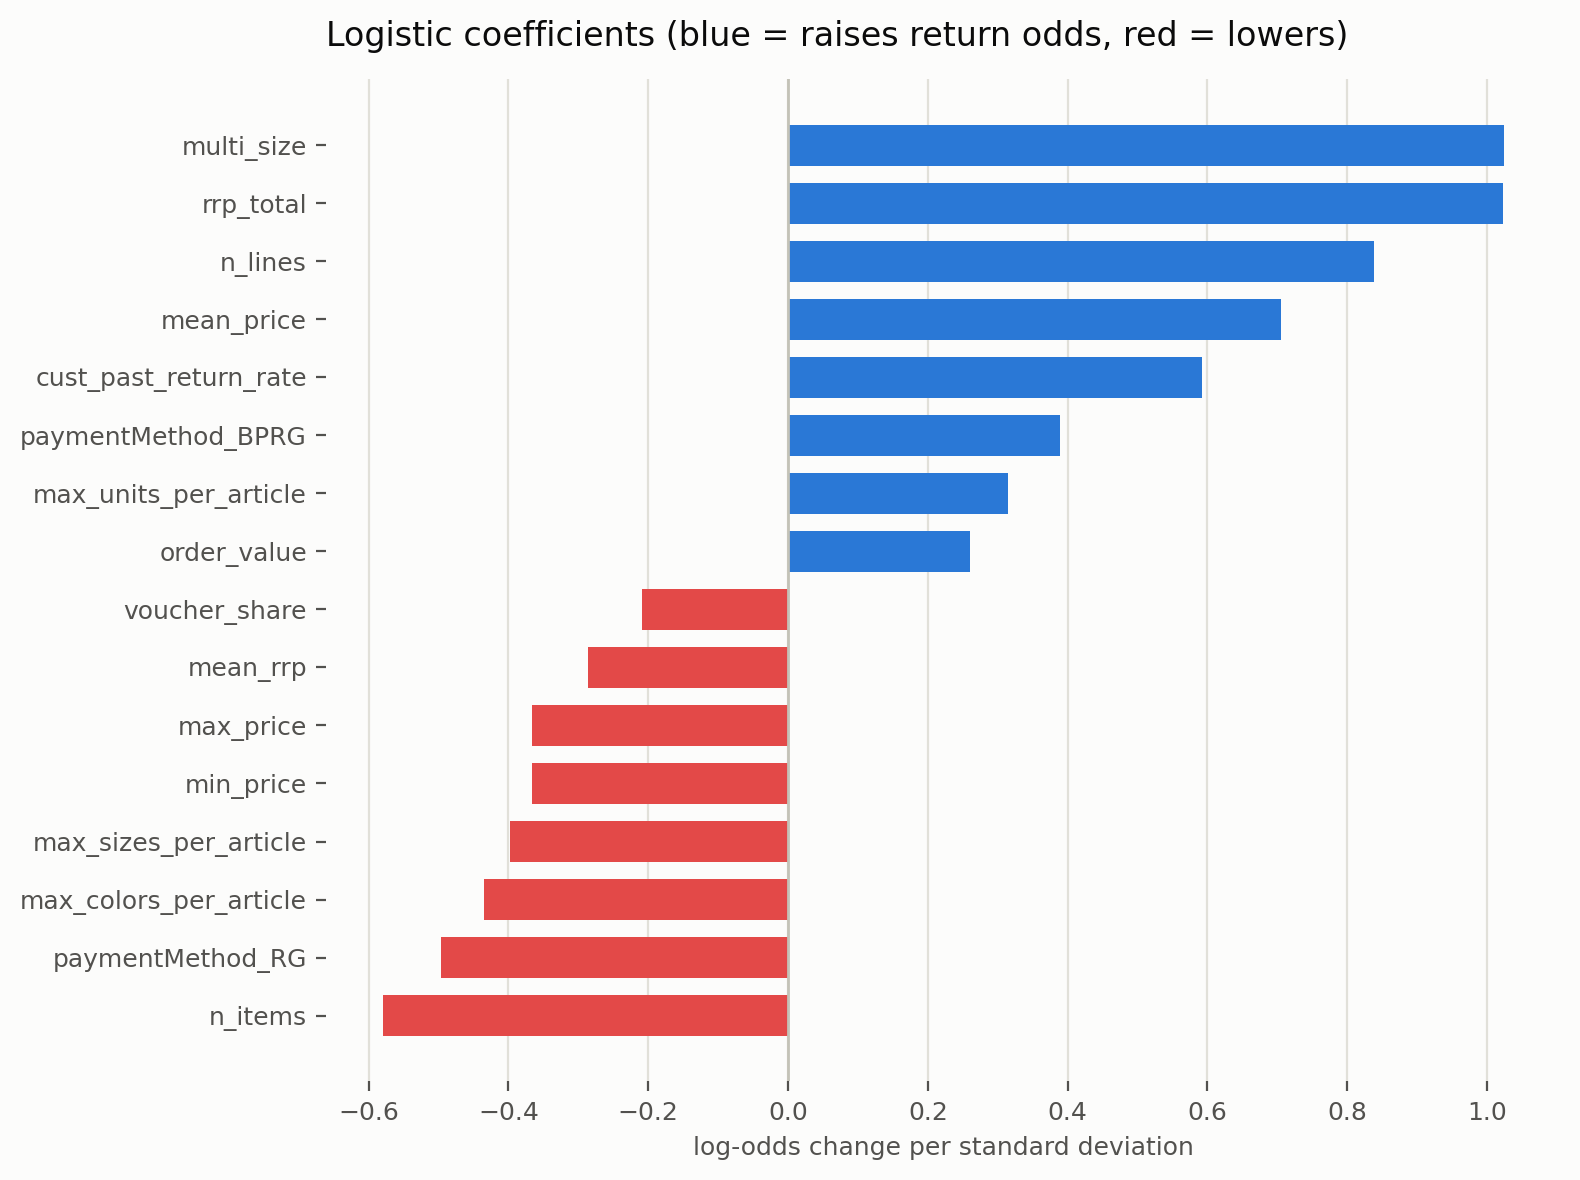

In [5]:
show = tbl.sort_values("coef_per_sd")
show = pd.concat([show.head(8), show.tail(8)])

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.barh(show.index, show.coef_per_sd, color=[NEG if v < 0 else POS for v in show.coef_per_sd],
        height=0.7, zorder=3)
ax.axvline(0, color=BASE, linewidth=1, zorder=4)
ax.grid(True, axis="x", color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("log-odds change per standard deviation", color=MUTED, fontsize=9)
ax.set_title("Logistic coefficients (blue = raises return odds, red = lowers)", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "regression_coefficients.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Against the tree

**Side by side with the trees.** Baseline, regression and LightGBM in one table. The gap from baseline to regression (+0.039 AUC) is the feature engineering; the gap from regression to LightGBM (+0.018) is everything non-linear the tree captures that the linear model cannot.

In [6]:
import json
model_res = json.loads((INTERIM / "model.json").read_text())
base_res = json.loads((INTERIM / "baseline.json").read_text())
cmp = pd.DataFrame([
    {"model": "raw-attribute LightGBM baseline", "auc": base_res["auc"], "logloss": base_res["logloss"]},
    {"model": "logistic regression (all features)", "auc": auc_lr, "logloss": ll_lr},
    {"model": "LightGBM (all features)", "auc": model_res["auc"], "logloss": model_res["logloss"]},
])
(INTERIM / "regression.json").write_text(json.dumps({"auc": auc_lr, "logloss": ll_lr}, indent=2))
cmp.round(4)

,model,auc,logloss
0,raw-attribute LightGBM baseline,0.7959,0.5218
1,logistic regression (all features),0.8348,0.4819
2,LightGBM (all features),0.8526,0.4527
